In [2]:
import numpy as np;
from k_means_methods import *;
from tensorflow.keras.datasets import mnist

## K means clustering

MNIST bestaat uit plaatjes van cijfers (0 t/m 9).
Elk plaatje is een lijst van 784 pixelwaardes.
Om data te comprimeren willen we K means clustering toepassen om prototypes te maken.

### Opdracht 1

Wat stelt één prototype voor?



Waarom is dit geheugenbesparend?

Schrijf een functie **load_mnist** die:

- De MNIST-data laadt

- De pixelwaarden (eventueel) schaalt naar 0–1


In [3]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In [4]:
train_images = [normalize_and_vectorize_image(img) for img in train_images]
test_images = [normalize_and_vectorize_image(img) for img in test_images]

In [12]:
prototypes = make_prototype(train_images, train_labels, 1)

finished for number 0
finished for number 1
finished for number 2
finished for number 3
finished for number 4
finished for number 5
finished for number 6
finished for number 7
finished for number 8
finished for number 9
finished computing prototypes


### Stap 2: Prototypes maken

We maken per cijfer een aantal prototypes (gemiddelde plaatjes).

Schrijf een functie **make_prototype** die:

- Voor elk cijfer (0–9) de bijbehorende trainingsbeelden selecteert

- Met K-means k clusters maakt

- Alle cluster-centers opslaat als prototypes

- Per prototype het juiste cijfer onthoudt

- Alle prototypes en bijbehorende labels in een datastructuur returnt


Hint:

- Gebruik een for-loop over de cijfer waardes (0 - 9)

- maak van elk van de waardes een lijstje van de afbeeldingen die erij horen

- Gebruik KMeans uit sklearn.cluster on van dit lijstje een prototype te maken


    **km = KMeans(n_clusters=k)**
    
    vindt K groepen in de data

    **km.fit(X_digit)**

    je kunt de cluster centers ( prototypes) achterhalen met:

    **km.cluster_centers_**


Bedenk goed dat je functie terug moet geven: prototypes en labels. Denk na over welke datastructuur je hiervoor wilt gebruiken.



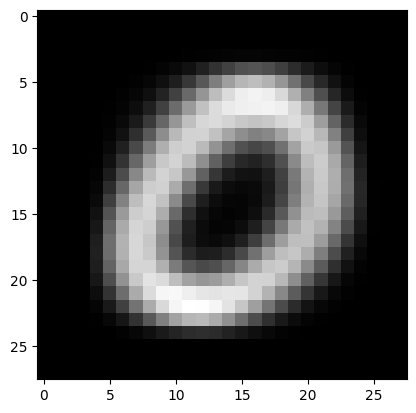

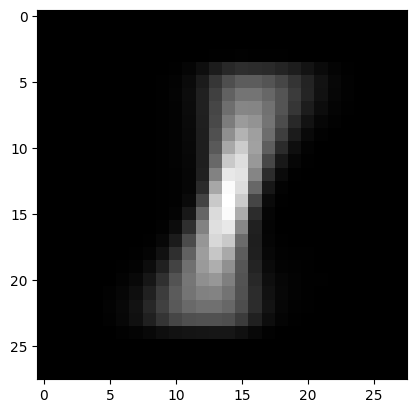

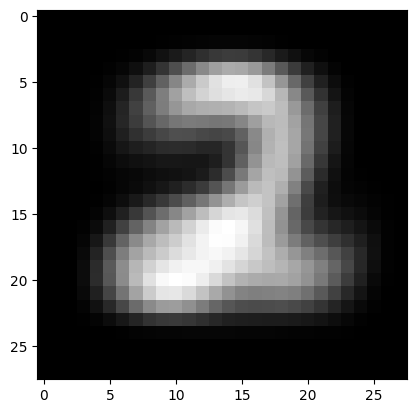

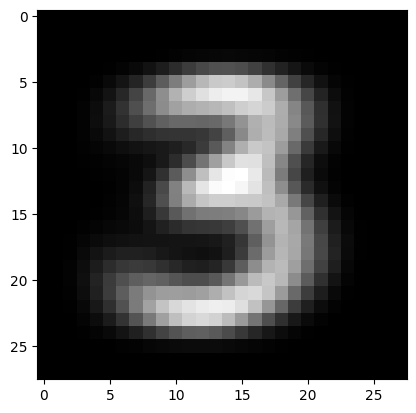

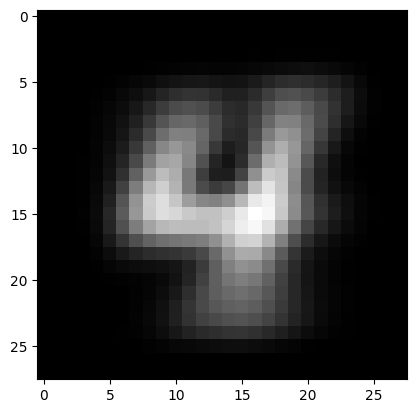

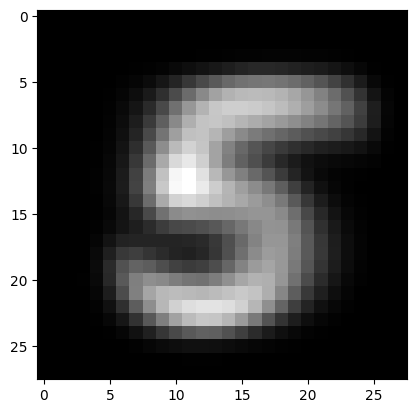

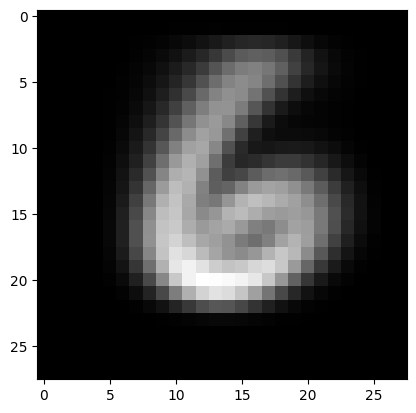

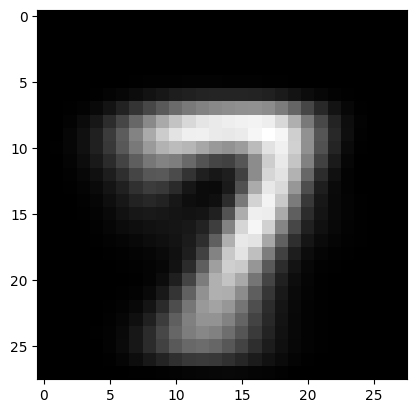

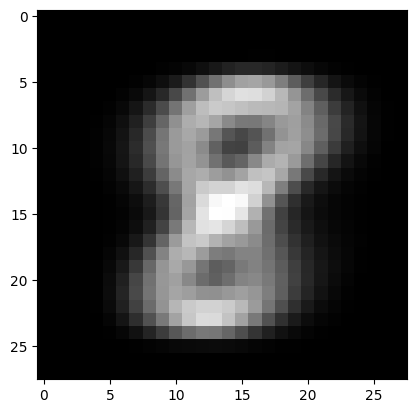

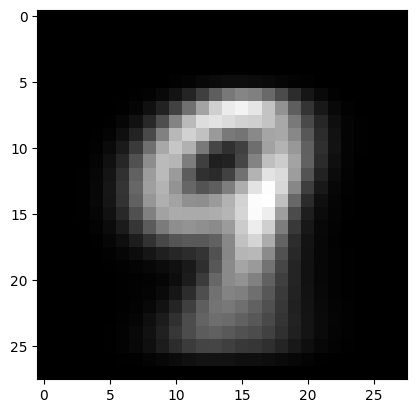

In [13]:
for key in prototypes:
    value = prototypes[key]
    for vec in value:
        img = vector_to_image(vec)
        show_image(img)

Maak nu een stukje code waarmee je de bovenstaande functies aanroept en een (of meer) van de prototypes laat zien.

### Stap 3 – Cijfers voorspellen

Stel we willen het cijfer voosrpellen foor te kijken naar de afstand tot een prototype. 
Een onbekend plaatje wordt dus vergeleken met alle prototypes.

Om te beginnen moeten we een functie hebben die de afstanden tussen 2 afbeeldingen (of een lijst van pixels) berekent.

Noem de functie **get_distance(image1, image2)**. deze geeft een getal terug die de som is van alle pixel verschillen.




Schrijf een functie **predict** die:

- Voor elk testplaatje de afstand tot alle prototypes berekent

- Het prototype kiest dat het meest lijkt

- Het bijbehorende cijfer - de label van de beste prototype teruggeeft

Wat betekent “afstand” hier?

Waarom gebruiken we de kleinste afstand?

Probeer nu een random afbeelding te voorspellen aan de hand van je **predict** functie.

In [16]:
determine_accuracy(prototypes, test_images, test_labels)

misses 1798
accuracy 82.02000000000001 %
{0: 102, 1: 43, 2: 251, 3: 195, 4: 169, 5: 282, 6: 132, 7: 172, 8: 256, 9: 196}


### Stap 4 – Experimenteren

Schrijf code die:

- De data splitst in train en test

- Prototypes maakt (aan de hand van je eerder gemaakte functie)

- Voorspellingen doet (predict functie aanroept)

- De accuracy berekent

- Het geheugengebruik van de prototypes print

Hint:

- Accuracy = aantal juiste voorspellingen / totaal

        Tip: gebruik **accuracy = np.mean(y_pred == y_test)**

- Geheugen = array.nbytes

Test met:

k = 1, 3, 5, 10 of iets anders...


Wat gebeurt er met de accuracy als k groter wordt?

Wat gebeurt er met het geheugen?

Probeer een optimale setting te vinden en bereid hier een presentatie over. 

Accuracy bij 1 prototypes per nummer:\
misses 1798\
accuracy 82.02000000000001 %\
{0: 102, 1: 43, 2: 251, 3: 195, 4: 169, 5: 282, 6: 132, 7: 172, 8: 256, 9: 196}

Accuracy bij 3 prototypes per nummer:
total 10_000\
misses 1195\
accuracy 88.05 %\
{0: 62, 1: 15, 2: 136, 3: 158, 4: 138, 5: 158, 6: 67, 7: 146, 8: 154, 9: 161}

Accuracy bij 10 prototypes per nummer:
total 10_000\
misses 916\
accuracy 90.84 %\
{0: 37, 1: 13, 2: 103, 3: 125, 4: 115, 5: 99, 6: 50, 7: 122, 8: 121, 9: 131}

Accuracy bij 30 prototypes per nummer:
total 10_000\
misses 640\
accuracy 93.60000000000001 %\
{0: 26, 1: 10, 2: 72, 3: 76, 4: 92, 5: 57, 6: 26, 7: 86, 8: 99, 9: 96}